# Schrödinger Bridge Tutorial: Modeling Cellular Aging

The **Schrödinger Bridge** solves the problem of finding the *most probable* stochastic process that transports one distribution into another.

In single-cell biology this means: given a snapshot of **young cells** and a snapshot of **old cells**, learn
- the most likely **aging trajectory** (young → old), and
- the most likely **rejuvenation trajectory** (old → young).

## When to use this (vs. the Hybrid Drift Field)

| Situation | Use |
|---|---|
| You have **two endpoint distributions** (e.g. young vs. old) | Schrödinger Bridge |
| You want the **true reverse process** (rejuvenation) | Schrödinger Bridge |
| You want **control factor discovery** / Jacobian analysis | Hybrid Drift Field |
| You have continuous pseudotime and RNA velocity | Hybrid Drift Field |

## What we will do

We use **2-dimensional synthetic data** so every step can be visualised directly — no PCA needed.

1. Generate young and old cell distributions
2. Compute the entropic Optimal Transport (OT) plan
3. Train the bridge (iterative Sinkhorn + score matching)
4. Simulate aging and rejuvenation trajectories
5. Visualise the learned drift field
6. Analyse local stability via the Jacobian

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch

from scqdiff.models.schrodinger_bridge import SchrodingerBridge, SchrodingerBridgeConfig
from scqdiff.transport.sinkhorn import compute_ot_plan, sinkhorn_divergence

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('Imports OK')
print(f'PyTorch {torch.__version__}')

Imports OK
PyTorch 2.11.0


## 1. Synthetic Data

We simulate two 2-D cell populations:

- **Young cells** — compact Gaussian centred near the origin, small variance
- **Old cells** — broader Gaussian shifted to the right, representing dysregulated gene expression

Think of the two axes as summary scores for two gene programs: *housekeeping* (x) and *stress response* (y).

In [2]:
DIM   = 2    # 2-D so we can plot everything directly
N     = 300  # cells per condition

# Young cells: tight cluster near origin
X_young = torch.randn(N, DIM) * 0.4

# Old cells: shifted right (+2.5) with higher variance (×2)
# The shift represents systematic expression changes with age.
# The larger variance represents transcriptional noise / dysregulation.
X_old = torch.randn(N, DIM) * 0.8 + torch.tensor([2.5, 0.5])

print(f'Young cells  N={N}  mean={X_young.mean(0).numpy()}  std={X_young.std(0).numpy()}')
print(f'Old cells    N={N}  mean={X_old.mean(0).numpy()}  std={X_old.std(0).numpy()}')

# Sinkhorn divergence ≈ Wasserstein distance (differentiable)
div = sinkhorn_divergence(X_young, X_old, epsilon=0.5)
print(f'\nSinkhorn divergence between distributions: {div.item():.3f}')

Young cells  N=300  mean=[0.03777286 0.01403819]  std=[0.37354174 0.43683726]
Old cells    N=300  mean=[2.5263207 0.5337913]  std=[0.8037986  0.77736384]

Sinkhorn divergence between distributions: 6.805


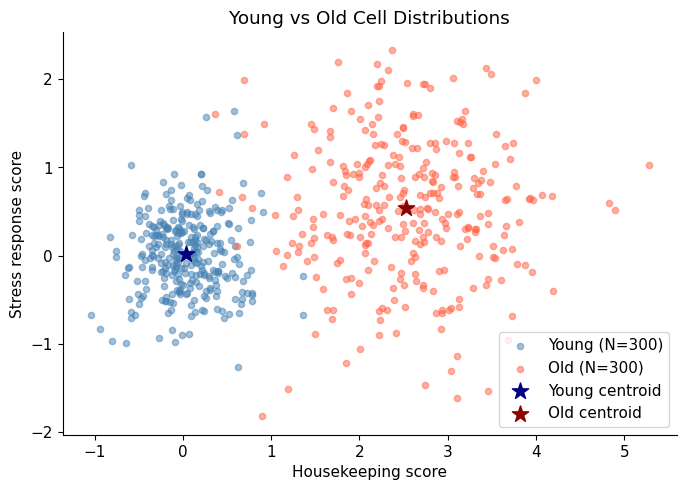

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(*X_young.T, s=20, alpha=0.5, color='steelblue', label=f'Young (N={N})')
ax.scatter(*X_old.T,   s=20, alpha=0.5, color='tomato',    label=f'Old (N={N})')

# Mark centroids
ax.scatter(*X_young.mean(0), s=150, color='navy',    marker='*', zorder=5, label='Young centroid')
ax.scatter(*X_old.mean(0),   s=150, color='darkred', marker='*', zorder=5, label='Old centroid')

ax.set_xlabel('Housekeeping score')
ax.set_ylabel('Stress response score')
ax.set_title('Young vs Old Cell Distributions')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('sb_fig1_distributions.png', bbox_inches='tight')
plt.show()

## 2. Entropic Optimal Transport Plan

Before training the bridge we can compute the OT coupling directly.

The Sinkhorn algorithm finds $P \in \mathbb{R}^{N \times M}$ (the *transport plan*) that minimises:
$$\min_{P} \; \langle C, P \rangle + \varepsilon \, H(P)$$
where $C_{ij} = \|x_i^{\text{young}} - x_j^{\text{old}}\|^2$ and $H(P)$ is the entropy of $P$.

$P_{ij}$ tells us how much *probability mass* young cell $i$ sends to old cell $j$ — i.e. **which young cells are most likely to become which old cells**.

In [4]:
P, _, _ = compute_ot_plan(X_young, X_old, epsilon=0.5, max_iter=200)

print(f'Transport plan shape: {P.shape}  (young × old)')
print(f'Plan sums to: {P.sum():.6f}  (should be 1.0)')

row_err = (P.sum(1) - 1/N).abs().max().item()
col_err = (P.sum(0) - 1/N).abs().max().item()
print(f'Marginal errors: row={row_err:.2e}  col={col_err:.2e}')

Transport plan shape: torch.Size([300, 300])  (young × old)
Plan sums to: 1.000000  (should be 1.0)
Marginal errors: row=3.96e-09  col=8.15e-09


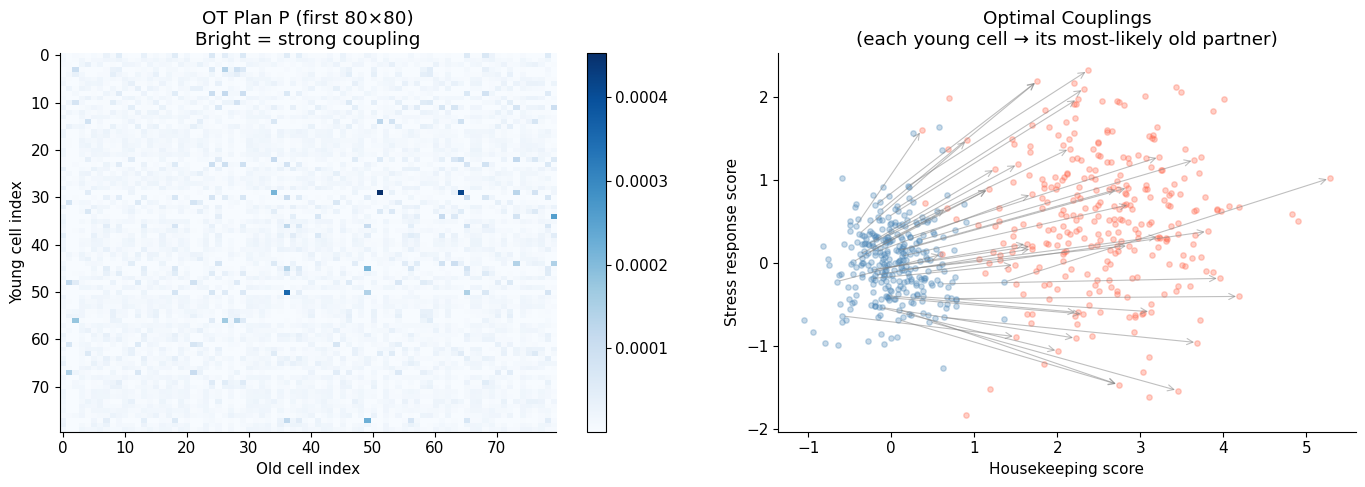

Young cells closest to the old cluster are most strongly coupled to nearby old cells.
This is the biological prior: nearby cells in state space are more likely paired.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: OT plan as a heatmap (first 80 cells each for readability) ---
ax = axes[0]
im = ax.imshow(P[:80, :80].numpy(), cmap='Blues', aspect='auto')
ax.set_xlabel('Old cell index')
ax.set_ylabel('Young cell index')
ax.set_title('OT Plan P (first 80×80)\nBright = strong coupling')
plt.colorbar(im, ax=ax)

# --- Right: draw the top transport arrows in cell space ---
ax = axes[1]
ax.scatter(*X_young.T, s=15, alpha=0.3, color='steelblue')
ax.scatter(*X_old.T,   s=15, alpha=0.3, color='tomato')

# For each young cell, draw an arrow to its top-coupled old cell
top_match = P.argmax(dim=1)   # (N,)
# Draw a random subset of 40 arrows for clarity
rng = np.random.default_rng(1)
arrow_idx = rng.choice(N, 40, replace=False)
for i in arrow_idx:
    j = top_match[i].item()
    xi, yi = X_young[i].numpy()
    xj, yj = X_old[j].numpy()
    ax.annotate('', xy=(xj, yj), xytext=(xi, yi),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8, alpha=0.5))

ax.set_xlabel('Housekeeping score')
ax.set_ylabel('Stress response score')
ax.set_title('Optimal Couplings\n(each young cell → its most-likely old partner)')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('sb_fig2_ot_plan.png', bbox_inches='tight')
plt.show()

print('Young cells closest to the old cluster are most strongly coupled to nearby old cells.')
print('This is the biological prior: nearby cells in state space are more likely paired.')

## 3. Train the Schrödinger Bridge

The bridge alternates between two steps each iteration:

1. **Compute OT plan** — Sinkhorn on $\{X_0, X_1\}$ gives coupling $P$
2. **Score matching** — sample pairs $(x_0, x_1) \sim P$, linearly interpolate, train forward and backward drift networks to point toward the endpoint

Training stops when the OT cost $\sum_{ij} P_{ij} C_{ij}$ stops decreasing (convergence criterion).

### Architecture
Both `forward_net` and `backward_net` are small time-conditioned MLPs:
$$\text{BridgeNet}(x, t): \mathbb{R}^D \times \mathbb{R} \to \mathbb{R}^D$$
The time $t$ is encoded via sinusoidal embeddings (same trick as in transformers).

In [6]:
cfg = SchrodingerBridgeConfig(
    dim=DIM,
    hidden=64,          # small network — data is 2-D
    depth=3,
    beta=0.05,          # diffusion coefficient (controls stochasticity)
    epsilon=0.5,        # Sinkhorn entropic regularisation
    sinkhorn_max_iter=200,
    sinkhorn_tol=1e-6,
    lr=3e-3,
    n_score_steps=150,  # gradient steps per bridge iteration
    convergence_tol=1e-4,
    patience=3,
    max_iterations=25,
)

bridge = SchrodingerBridge(cfg, X_young, X_old)

fwd_params = sum(p.numel() for p in bridge.forward_net.parameters())
bwd_params = sum(p.numel() for p in bridge.backward_net.parameters())
print(f'Forward network:  {fwd_params:,} parameters')
print(f'Backward network: {bwd_params:,} parameters')
print(f'Total:            {fwd_params + bwd_params:,} parameters')
print(f'\nMax iterations: {cfg.max_iterations}  '
      f'({cfg.n_score_steps} gradient steps each)')

Forward network:  8,578 parameters
Backward network: 8,578 parameters
Total:            17,156 parameters

Max iterations: 25  (150 gradient steps each)


In [7]:
print('Training Schrödinger Bridge...')
print('(each iteration: compute OT plan → train forward → train backward)')
print('=' * 60)

history = bridge.train_bridge(
    n_iterations=None,   # use cfg.max_iterations (with early stopping)
    batch_size=256,
    verbose=True,
)

print(f"\nTraining finished.")
print(f"  Iterations run: {history['n_iters']}")
print(f"  Converged:      {history['converged']}")
print(f"  Final OT cost:  {history['ot_costs'][-1]:.4f}")

Training Schrödinger Bridge...
(each iteration: compute OT plan → train forward → train backward)


Bridge iterations:  12%| | 3/25 [00:00<00:04,  5.13it/s, OT=7.1810, bwd=0.2127, fwd=0.2130, no_imp=


✓ Converged at iteration 4 (|ΔCOST| = 0.00e+00 < tol=1.00e-04 for 3 consecutive iters).

Training finished.
  Iterations run: 4
  Converged:      True
  Final OT cost:  7.1810


## 4. Training Curves

The OT cost should decrease toward a plateau — that is the convergence signal.
Forward and backward score losses should also decrease, indicating the drift networks are learning.

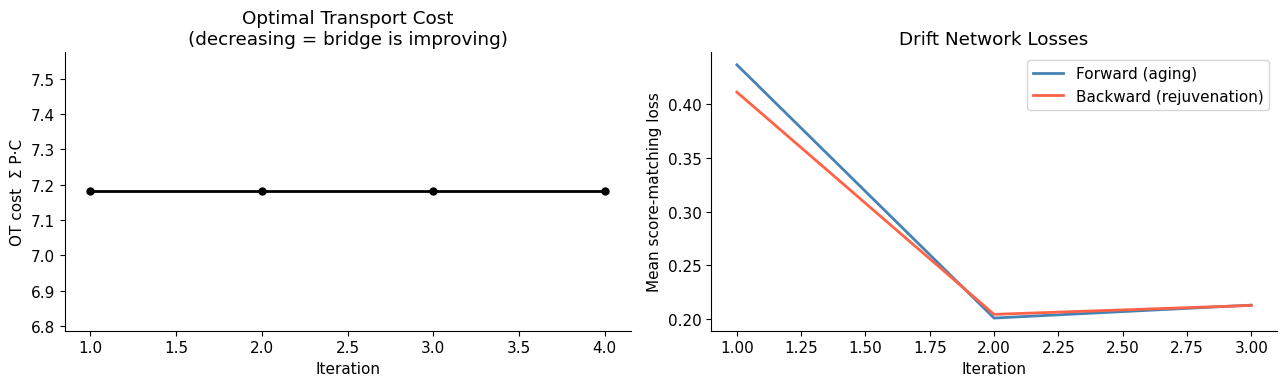

In [8]:
       # ot_costs gets one extra entry when early stopping fires after the OT step
       # but before network training — use separate index arrays for each series
       iters_ot   = np.arange(1, len(history['ot_costs'])       + 1)
       iters_loss = np.arange(1, len(history['forward_losses'])  + 1)                                                                                              

       fig, axes = plt.subplots(1, 2, figsize=(13, 4))                                                                                                             

       ax = axes[0]
       ax.plot(iters_ot, history['ot_costs'], 'o-', color='black', lw=2, ms=5)
       ax.set_xlabel('Iteration')
       ax.set_ylabel('OT cost  Σ P·C')
       ax.set_title('Optimal Transport Cost\n(decreasing = bridge is improving)')

       ax = axes[1]
       ax.plot(iters_loss, history['forward_losses'],  label='Forward (aging)',         color='steelblue', lw=2)                                                   
       ax.plot(iters_loss, history['backward_losses'], label='Backward (rejuvenation)', color='tomato',    lw=2)                                                   
       ax.set_xlabel('Iteration')
       ax.set_ylabel('Mean score-matching loss')
       ax.set_title('Drift Network Losses')
       ax.legend()

       plt.tight_layout()
       plt.savefig('sb_fig3_training.png', bbox_inches='tight')
       plt.show()

## 5. Simulate Trajectories

With the bridge trained we can simulate:
- **Forward** (`forward_integrate`): young cell → old state (aging)
- **Backward** (`backward_integrate`): old cell → young state (rejuvenation)

Both deterministic (ODE) and stochastic (SDE) integration are available.

In [9]:
N_TRAJ = 15   # trajectories to display
STEPS  = 120  # integration steps

# Pick cells spread across the young / old distributions
rng = np.random.default_rng(7)
young_sel = X_young[rng.choice(N, N_TRAJ, replace=False)]
old_sel   = X_old[  rng.choice(N, N_TRAJ, replace=False)]

# Simulate
aging_traj = bridge.forward_integrate(young_sel,  steps=STEPS, stochastic=False)  # (N_TRAJ, STEPS+1, DIM)
rejuv_traj = bridge.backward_integrate(old_sel,   steps=STEPS, stochastic=False)

aging_traj_s = bridge.forward_integrate(young_sel, steps=STEPS, stochastic=True)
rejuv_traj_s = bridge.backward_integrate(old_sel,  steps=STEPS, stochastic=True)

print(f'Trajectory shape: {aging_traj.shape}  (cells × time_steps × dim)')

# Endpoint accuracy: how close are simulated endpoints to the target distribution?
aging_end  = aging_traj[:, -1, :]   # (N_TRAJ, DIM)
rejuv_end  = rejuv_traj[:, -1, :]

dist_aging = torch.cdist(aging_end, X_old).min(1).values.mean().item()
dist_rejuv = torch.cdist(rejuv_end, X_young).min(1).values.mean().item()
print(f'Mean distance of aged endpoints to old distribution:        {dist_aging:.4f}')
print(f'Mean distance of rejuvenated endpoints to young distribution: {dist_rejuv:.4f}')

Trajectory shape: torch.Size([15, 121, 2])  (cells × time_steps × dim)
Mean distance of aged endpoints to old distribution:        0.1161
Mean distance of rejuvenated endpoints to young distribution: 0.0631


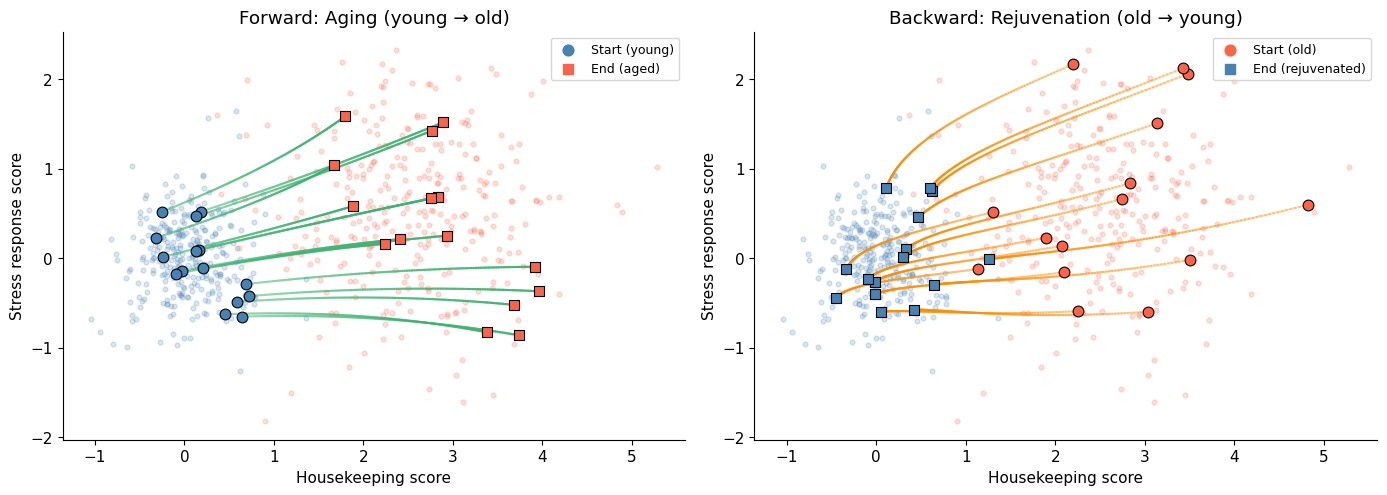

In [10]:
def plot_trajectories(ax, bg_young, bg_old, trajs, start_color, end_color,
                      line_color, title, start_label, end_label):
    ax.scatter(*bg_young.T, s=12, alpha=0.2, color='steelblue')
    ax.scatter(*bg_old.T,   s=12, alpha=0.2, color='tomato')
    for traj in trajs.numpy():
        # Colour the line by time (early=light, late=dark)
        for k in range(len(traj) - 1):
            alpha = 0.3 + 0.6 * k / len(traj)
            ax.plot(traj[k:k+2, 0], traj[k:k+2, 1],
                    color=line_color, lw=1.5, alpha=alpha)
        ax.scatter(*traj[0],  s=60, color=start_color, marker='o',
                   edgecolors='black', lw=0.8, zorder=5)
        ax.scatter(*traj[-1], s=60, color=end_color,   marker='s',
                   edgecolors='black', lw=0.8, zorder=5)
    # Legend proxies
    ax.scatter([], [], color=start_color, marker='o', s=60, label=start_label)
    ax.scatter([], [], color=end_color,   marker='s', s=60, label=end_label)
    ax.set_title(title)
    ax.set_xlabel('Housekeeping score')
    ax.set_ylabel('Stress response score')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_trajectories(axes[0], X_young, X_old, aging_traj,
                  'steelblue', 'tomato', 'mediumseagreen',
                  'Forward: Aging (young → old)',
                  'Start (young)', 'End (aged)')

plot_trajectories(axes[1], X_young, X_old, rejuv_traj,
                  'tomato', 'steelblue', 'darkorange',
                  'Backward: Rejuvenation (old → young)',
                  'Start (old)', 'End (rejuvenated)')

plt.tight_layout()
plt.savefig('sb_fig4_trajectories.png', bbox_inches='tight')
plt.show()

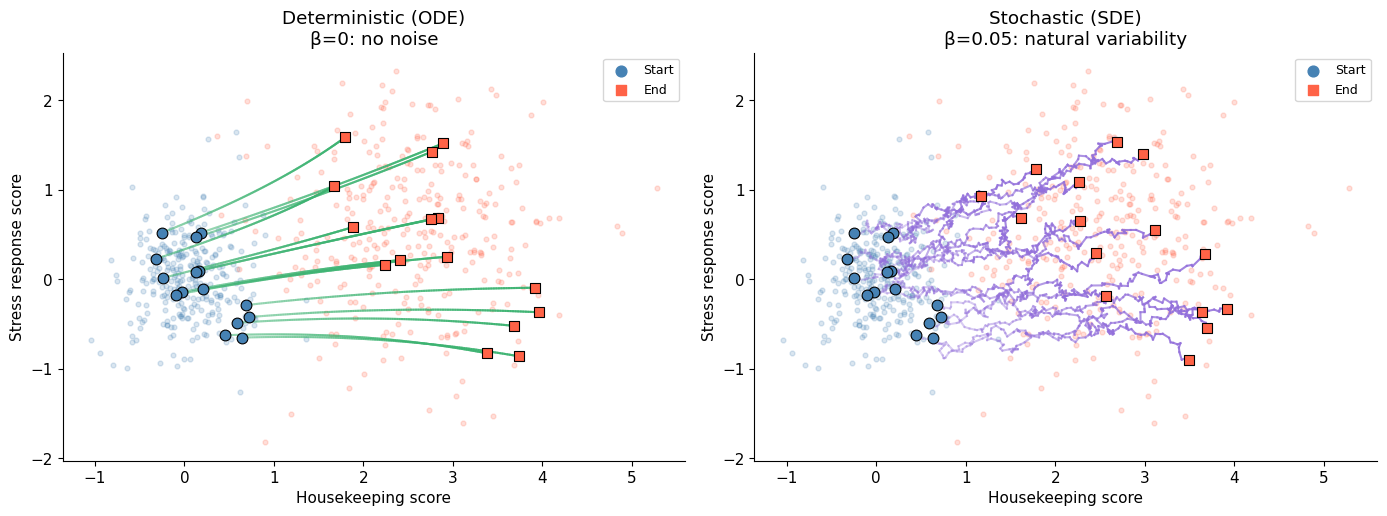

Stochastic trajectories produce a family of possible aging paths.
This captures biological variability — not all cells age the same way.


In [11]:
# Stochastic vs deterministic comparison (forward only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_trajectories(axes[0], X_young, X_old, aging_traj,
                  'steelblue', 'tomato', 'mediumseagreen',
                  'Deterministic (ODE)\nβ=0: no noise', 'Start', 'End')

plot_trajectories(axes[1], X_young, X_old, aging_traj_s,
                  'steelblue', 'tomato', 'mediumpurple',
                  f'Stochastic (SDE)\nβ={cfg.beta}: natural variability', 'Start', 'End')

plt.tight_layout()
plt.savefig('sb_fig5_stochastic.png', bbox_inches='tight')
plt.show()

print('Stochastic trajectories produce a family of possible aging paths.')
print('This captures biological variability — not all cells age the same way.')

## 6. Visualise the Learned Drift Field

Because our data is 2-D we can plot the drift vector $f(x, t)$ on a grid — a **quiver plot**. This shows the direction and strength of the learned force that drives cells from young to old (or vice versa) at each point in state space.

We inspect three time slices: early ($t=0.1$), mid ($t=0.5$), and late ($t=0.9$).

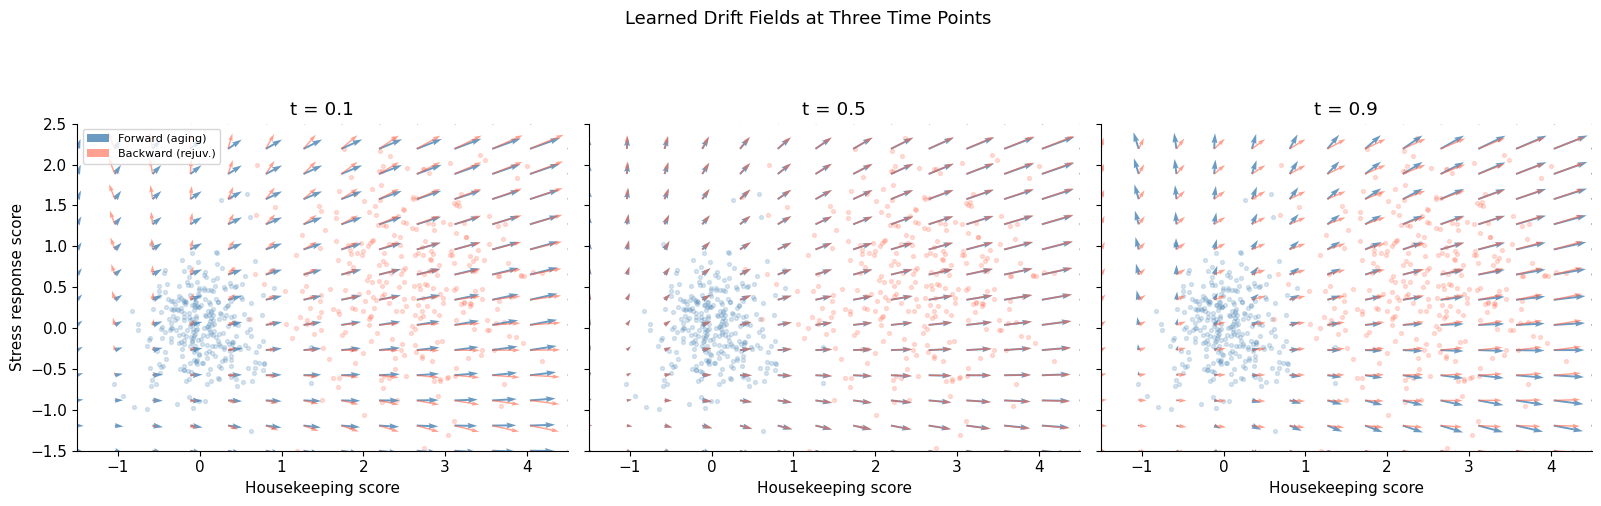

Blue arrows = forward drift (pushes cells toward old distribution).
Red arrows  = backward drift (pushes cells toward young distribution).
The field rotates as t changes — the bridge adapts its force over time.


In [12]:
# Build a 2-D grid covering both distributions
xmin, xmax = -1.5, 4.5
ymin, ymax = -1.5, 2.5
res = 14   # grid resolution

gx = np.linspace(xmin, xmax, res)
gy = np.linspace(ymin, ymax, res)
GX, GY = np.meshgrid(gx, gy)
grid_pts = torch.tensor(
    np.stack([GX.ravel(), GY.ravel()], axis=1), dtype=torch.float32
)  # (res², 2)

t_vals = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

bridge.forward_net.eval()
bridge.backward_net.eval()

with torch.no_grad():
    for ax, t_val in zip(axes, t_vals):
        t_batch = torch.full((grid_pts.shape[0],), t_val)

        fwd = bridge.forward_net(grid_pts, t_batch).numpy()   # (res², 2)
        bwd = bridge.backward_net(grid_pts, t_batch).numpy()

        U_f, V_f = fwd[:, 0].reshape(res, res), fwd[:, 1].reshape(res, res)
        U_b, V_b = bwd[:, 0].reshape(res, res), bwd[:, 1].reshape(res, res)

        # Background: cell distributions
        ax.scatter(*X_young.T, s=8, alpha=0.2, color='steelblue')
        ax.scatter(*X_old.T,   s=8, alpha=0.2, color='tomato')

        # Forward drift (blue) and backward drift (red)
        ax.quiver(GX, GY, U_f, V_f, color='steelblue', alpha=0.8,
                  scale=None, width=0.004, label='Forward (aging)')
        ax.quiver(GX, GY, U_b, V_b, color='tomato', alpha=0.6,
                  scale=None, width=0.003, label='Backward (rejuv.)')

        ax.set_title(f't = {t_val}')
        ax.set_xlabel('Housekeeping score')
        if ax is axes[0]:
            ax.set_ylabel('Stress response score')
            ax.legend(fontsize=8, loc='upper left')
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect('equal')

plt.suptitle('Learned Drift Fields at Three Time Points', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sb_fig6_drift_field.png', bbox_inches='tight')
plt.show()

print('Blue arrows = forward drift (pushes cells toward old distribution).')
print('Red arrows  = backward drift (pushes cells toward young distribution).')
print('The field rotates as t changes — the bridge adapts its force over time.')

## 7. Jacobian Analysis

The **Jacobian** $J(x, t) = \partial f / \partial x$ tells us how sensitive the drift is to small changes in cell state at each point in time.

Eigenvalues of $J$ reveal local dynamics:

| Eigenvalue | Meaning |
|---|---|
| $\lambda < 0$ | Stable — cells are pulled back if perturbed |
| $\lambda \approx 0$ | Neutral — drift is locally flat |
| $\lambda > 0$ | Unstable — small perturbations amplify |

For a 2-D bridge, $J$ is a $2 \times 2$ matrix — we can compute it exactly for a batch of cells.

In [13]:
# Compute Jacobian of the forward drift at a set of test points and t=0.5
n_test = 60
x_test = torch.cat([X_young[:n_test//2], X_old[:n_test//2]])
t_test = torch.full((n_test,), 0.5)

J = bridge.jacobian(x_test, t_test, forward=True)  # (n_test, 2, 2)

# Eigenvalues
eig = torch.linalg.eigvals(J).real   # (n_test, 2) — real parts
lam_max = eig.max(dim=1).values      # (n_test,) max eigenvalue per cell

print(f'Jacobian shape: {J.shape}  (cells × D × D)')
print(f'\nMax eigenvalue across cells:')
print(f'  Mean: {lam_max.mean().item():.4f}')
print(f'  Std:  {lam_max.std().item():.4f}')
print(f'  Min:  {lam_max.min().item():.4f}')
print(f'  Max:  {lam_max.max().item():.4f}')

Jacobian shape: torch.Size([60, 2, 2])  (cells × D × D)

Max eigenvalue across cells:
  Mean: 0.9027
  Std:  0.0855
  Min:  0.7651
  Max:  1.0246


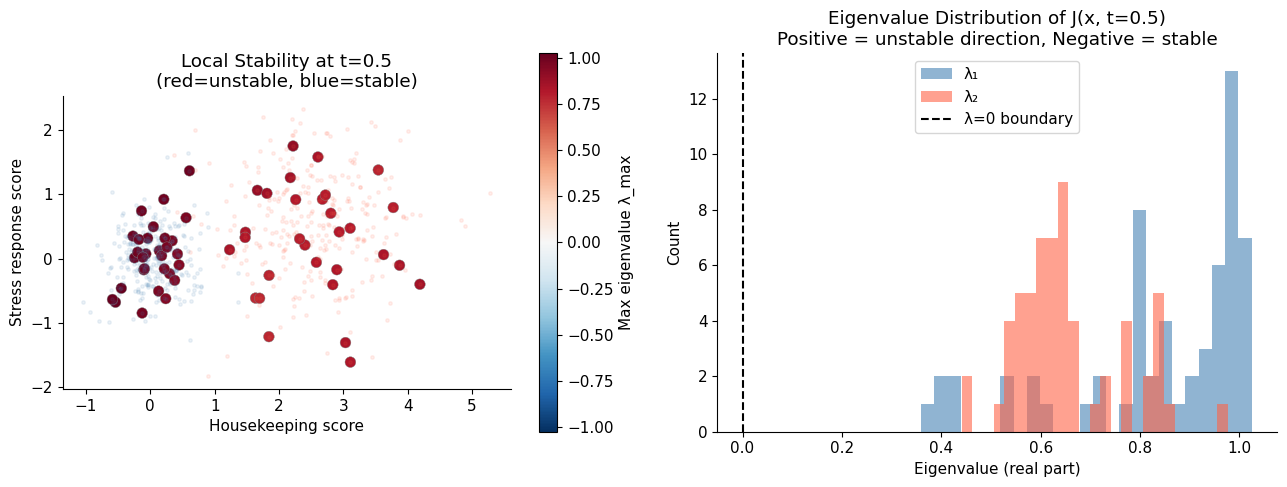

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Max eigenvalue by cell (scatter coloured by λ_max) ---
ax = axes[0]
lam_np = lam_max.numpy()
vabs = np.abs(lam_np).max()
sc = ax.scatter(x_test[:, 0].numpy(), x_test[:, 1].numpy(),
                c=lam_np, cmap='RdBu_r', vmin=-vabs, vmax=vabs, s=60, edgecolors='gray', lw=0.3)
plt.colorbar(sc, ax=ax, label='Max eigenvalue λ_max')
ax.scatter(*X_young.T, s=6, alpha=0.1, color='steelblue')
ax.scatter(*X_old.T,   s=6, alpha=0.1, color='tomato')
ax.set_xlabel('Housekeeping score')
ax.set_ylabel('Stress response score')
ax.set_title('Local Stability at t=0.5\n(red=unstable, blue=stable)')
ax.set_aspect('equal')

# --- Distribution of eigenvalues ---
ax = axes[1]
ax.hist(eig[:, 0].numpy(), bins=25, alpha=0.6, color='steelblue', label='λ₁')
ax.hist(eig[:, 1].numpy(), bins=25, alpha=0.6, color='tomato',    label='λ₂')
ax.axvline(0, color='black', lw=1.5, linestyle='--', label='λ=0 boundary')
ax.set_xlabel('Eigenvalue (real part)')
ax.set_ylabel('Count')
ax.set_title('Eigenvalue Distribution of J(x, t=0.5)\n'
             'Positive = unstable direction, Negative = stable')
ax.legend()

plt.tight_layout()
plt.savefig('sb_fig7_jacobian.png', bbox_inches='tight')
plt.show()

## 8. Round-trip Consistency

A good bridge should be approximately invertible: aging a young cell and then rejuvenating it should return close to the original state. We measure this round-trip error.

Round-trip error (young → old → young):
  Mean absolute:  0.1815
  Mean relative:  51.2%
  Std:            0.0150


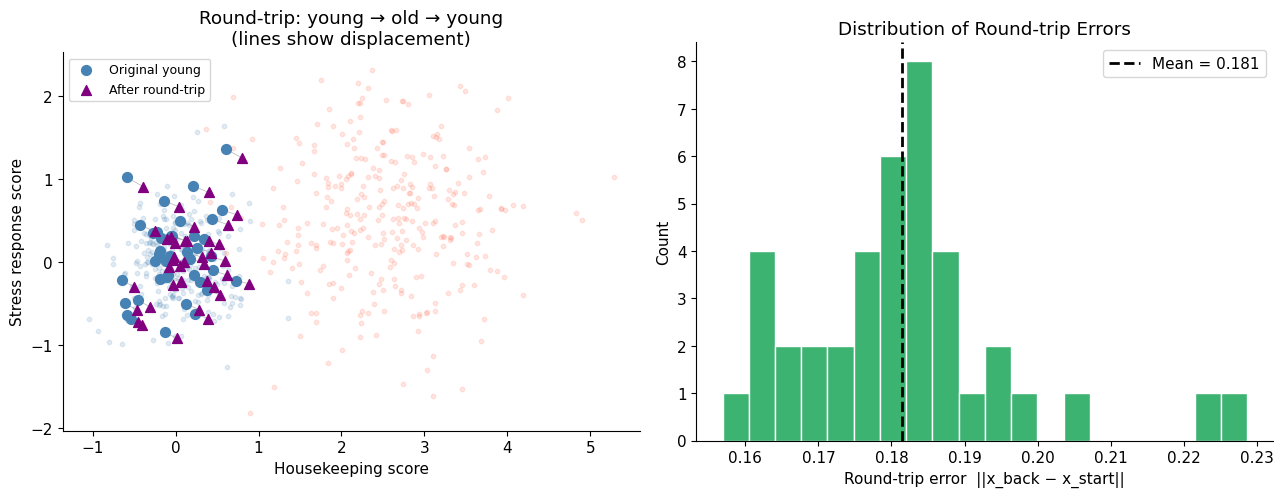

In [15]:
n_rt = 40
x_start = X_young[:n_rt]                                          # (40, 2) — young
x_aged  = bridge.forward_integrate(x_start,  steps=100, stochastic=False)[:, -1, :]  # aged
x_back  = bridge.backward_integrate(x_aged,  steps=100, stochastic=False)[:, -1, :]  # back to young

error = (x_back - x_start).norm(dim=1)   # (40,)
rel_error = error / (x_start.norm(dim=1) + 1e-8)

print(f'Round-trip error (young → old → young):')
print(f'  Mean absolute:  {error.mean().item():.4f}')
print(f'  Mean relative:  {rel_error.mean().item()*100:.1f}%')
print(f'  Std:            {error.std().item():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(*X_young.T, s=10, alpha=0.15, color='steelblue')
ax.scatter(*X_old.T,   s=10, alpha=0.15, color='tomato')
ax.scatter(*x_start.T, s=50, color='steelblue', marker='o', label='Original young', zorder=4)
ax.scatter(*x_back.T,  s=50, color='purple',     marker='^', label='After round-trip', zorder=4)
for i in range(n_rt):
    ax.plot([x_start[i, 0], x_back[i, 0]],
            [x_start[i, 1], x_back[i, 1]],
            'gray', lw=0.6, alpha=0.5)
ax.set_title('Round-trip: young → old → young\n(lines show displacement)')
ax.set_xlabel('Housekeeping score')
ax.set_ylabel('Stress response score')
ax.legend(fontsize=9)
ax.set_aspect('equal')

ax = axes[1]
ax.hist(error.numpy(), bins=20, color='mediumseagreen', edgecolor='white')
ax.axvline(error.mean().item(), color='black', lw=2, linestyle='--',
           label=f'Mean = {error.mean().item():.3f}')
ax.set_xlabel('Round-trip error  ||x_back − x_start||')
ax.set_ylabel('Count')
ax.set_title('Distribution of Round-trip Errors')
ax.legend()

plt.tight_layout()
plt.savefig('sb_fig8_roundtrip.png', bbox_inches='tight')
plt.show()

## 9. Summary

### What we learned

| Component | What it does | API |
|---|---|---|
| `SchrodingerBridgeConfig` | Set network size, β, ε, training budget | `SchrodingerBridgeConfig(dim=..., ...)` |
| `SchrodingerBridge` | Holds both drift networks + endpoint data | `SchrodingerBridge(cfg, X_0, X_1)` |
| `train_bridge()` | Iterative Sinkhorn + score matching | `bridge.train_bridge(batch_size=256)` |
| `forward_integrate()` | Aging trajectory simulation | `bridge.forward_integrate(x0, steps=100)` |
| `backward_integrate()` | Rejuvenation trajectory simulation | `bridge.backward_integrate(x1, steps=100)` |
| `jacobian()` | Local stability at each cell | `bridge.jacobian(x, t, forward=True)` |
| `forward_net(x, t)` | Raw drift vector (forward) | direct call |
| `backward_net(x, t)` | Raw drift vector (backward) | direct call |

### Key hyperparameters

| Parameter | Effect | Typical range |
|---|---|---|
| `epsilon` | Sinkhorn regularisation — larger = smoother OT plan | 0.05 – 1.0 |
| `beta` | Diffusion coefficient — larger = more stochastic trajectories | 0.01 – 0.5 |
| `n_score_steps` | Gradient steps per bridge iteration | 50 – 500 |
| `max_iterations` | Outer Sinkhorn-update iterations | 10 – 50 |
| `hidden` / `depth` | Network capacity | 64–512 / 2–6 |

### Next steps

```python
# Apply to real data via the training pipeline
from scqdiff.pipeline.train_bridge import train_bridge_from_anndata

model, history = train_bridge_from_anndata(
    adata,
    source_key='age_group',
    target_key='age_group',
    source_value='young',
    target_value='old',
    cfg=SchrodingerBridgeConfig(dim=adata.n_vars, ...),
)
```

For datasets with known cell types and clear endpoint distributions (aging, perturbation response, development), the Schrödinger Bridge gives you **both the most probable forward path and its true reversal** — something the Hybrid Drift Field alone cannot provide.

In [16]:
print('=' * 55)
print('Schrödinger Bridge Tutorial — Complete')
print('=' * 55)
print(f'Data:          2-D synthetic  (N={N} young, N={N} old)')
print(f'Bridge:        {sum(p.numel() for p in bridge.parameters()):,} parameters total')
print(f'Iterations:    {history["n_iters"]}  (converged={history["converged"]})')
print(f'Final OT cost: {history["ot_costs"][-1]:.4f}')
print(f'Round-trip:    {error.mean().item():.4f} mean displacement')
print()
print('Figures saved:')
for i, name in enumerate([
    'sb_fig1_distributions.png',
    'sb_fig2_ot_plan.png',
    'sb_fig3_training.png',
    'sb_fig4_trajectories.png',
    'sb_fig5_stochastic.png',
    'sb_fig6_drift_field.png',
    'sb_fig7_jacobian.png',
    'sb_fig8_roundtrip.png',
], 1):
    print(f'  {i}. {name}')

Schrödinger Bridge Tutorial — Complete
Data:          2-D synthetic  (N=300 young, N=300 old)
Bridge:        17,156 parameters total
Iterations:    4  (converged=True)
Final OT cost: 7.1810
Round-trip:    0.1815 mean displacement

Figures saved:
  1. sb_fig1_distributions.png
  2. sb_fig2_ot_plan.png
  3. sb_fig3_training.png
  4. sb_fig4_trajectories.png
  5. sb_fig5_stochastic.png
  6. sb_fig6_drift_field.png
  7. sb_fig7_jacobian.png
  8. sb_fig8_roundtrip.png
